In [13]:
import slmcontrol
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from cameras.ImagingSourceNew import ImagingSourceCamera
from cameras.Ximea import XimeaCamera
from scipy.linalg import inv, norm
from utils import generate_amplitude_and_phase_hologram
from phase_screens import fourier_phase_screen
from augmented_gs import augmented_gs, fidelity
import jax
from utils import crop_center, resize_and_center

def remove_background(img, bg):
    return np.where(img > bg, img - bg, 0)

def capture_images(mode, phase, camera_direct, camera_fourier, roi_direct, roi_fourier, slm, bg_direct, bg_fourier):
    holo1 = generate_amplitude_and_phase_hologram(mode, np.zeros_like(mode), 192, -3, 19)
    slm.updateArray(holo1)
    image_direct = camera_direct.capture(roi=roi_direct)
    image_fourier = camera_fourier.capture(roi=roi_fourier)

    holo2 = generate_amplitude_and_phase_hologram(mode, phase, 192, -3, 19)
    slm.updateArray(holo2)
    image_phase_fourier = camera_fourier.capture(roi=roi_fourier)

    image_direct = remove_background(image_direct, bg_direct)
    image_fourier = remove_background(image_fourier, bg_fourier)
    image_phase_fourier = remove_background(image_phase_fourier, bg_fourier)

    return image_direct, image_fourier, image_phase_fourier

def second_moment(image):
    """
    Compute second moments (variance) of an image.

    Parameters
    ----------
    image : ndarray (H, W)
        Intensity image (non-negative).

    Returns
    -------
    sigma_y, sigma_x : float
        Standard deviations along y and x.
    """
    image = np.asarray(image, dtype=float)

    total = image.sum()
    if total <= 0:
        return np.nan, np.nan

    y, x = np.indices(image.shape)

    # --- centroid ---
    y0 = (y * image).sum() / total
    x0 = (x * image).sum() / total

    # --- second moments ---
    var_y = ((y - y0)**2 * image).sum() / total
    var_x = ((x - x0)**2 * image).sum() / total

    sigma_y = np.sqrt(var_y)
    sigma_x = np.sqrt(var_x)

    return sigma_y, sigma_x

def find_alpha(image_direct, image_fourier, A_direct, A_fourier, n=5, order=5):
    alphay = 1
    alphax = 1
    sy2, sx2 = second_moment(image_fourier)
    for _ in range(n):
        transformed = transform_direct_to_fourier_conjugate(image_direct,A_direct,A_fourier,order=order,alpha = (alphay, alphax))
        ft_transformed = np.abs(fourier_transform(np.sqrt(transformed)))**2
        sy1, sx1 = second_moment(ft_transformed)
        alphay *= sy1 / sy2
        alphax *= sx1 / sx2
    return alphay, alphax

def transform_direct_to_fourier_conjugate(
    image_direct,
    A_direct,
    A_fourier,
    output_shape=None,
    order = 5,
    alpha = [1, 1]
):
    """
    Transform a direct-plane image so that its FFT is conjugate to the Fourier camera grid.

    Parameters
    ----------
    image_direct : ndarray (H, W)
        Direct camera image.

    A_direct, t_direct : ndarray
        Affine transform from SLM → direct camera.

    A_fourier, t_fourier : ndarray
        Affine transform from SLM → Fourier camera.

    output_shape : tuple, optional
        Shape of output image (default: same as input).

    order : int
        Interpolation order (1 = bilinear, 3 = cubic).

    center : bool
        If True, apply transform around image center.

    Returns
    -------
    transformed : ndarray
        Direct image resampled onto Fourier-conjugate grid.
    """

    M = A_fourier @ np.linalg.inv(A_direct)
    # T = alpha * np.linalg.inv(M).T

    A_scipy = np.linalg.inv(M) @ np.diag([1/alpha[0], 1/alpha[1]])

    if not output_shape:
        output_shape = image_direct.shape

    # ONLY center-based alignment
    in_center = (np.array(image_direct.shape) - 1) / 2
    out_center = (np.array(output_shape) - 1) / 2

    offset = in_center - A_scipy @ out_center

    # --- Step 6: apply transform ---
    transformed = affine_transform(
        image_direct,
        matrix=A_scipy,
        offset=offset,
        output_shape=output_shape,
        order=order,
        mode="constant",
        cval=0.0
    )

    return transformed

def fourier_transform(mode):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(mode)))

def inverse_fourier_transform(mode):
    return np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(mode)))


In [2]:
slm = slmcontrol.SLMDisplay(host="localhost")
Ny, Nx = slm.height, slm.width // 2
_xs = np.arange(Nx) - Nx // 2
_ys = np.arange(Ny) - Ny // 2
xs, ys = np.meshgrid(_xs, _ys)

with h5py.File("calibration/calibration.h5") as f:
    A_direct = f["A_direct"][:]
    t_direct = f["t_direct"][:]
    A_fourier = f["A_fourier"][:]
    t_fourier = f["t_fourier"][:]
    roi_direct = f["roi_direct"][:]
    roi_fourier = f["roi_fourier"][:]

In [3]:
camera_direct = ImagingSourceCamera()
camera_fourier = XimeaCamera()

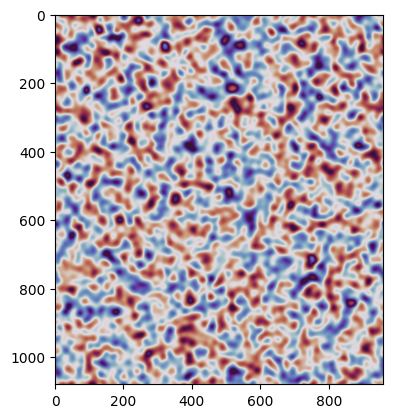

In [10]:
amplitude = 2**26
sigma = 0.5 / 2 / np.pi

phase_mask = fourier_phase_screen(slm.height, slm.width // 2, amplitude=amplitude, sigma=sigma)
phase_transformation = np.exp(1j * phase_mask)

plt.imshow(phase_mask, cmap="twilight")

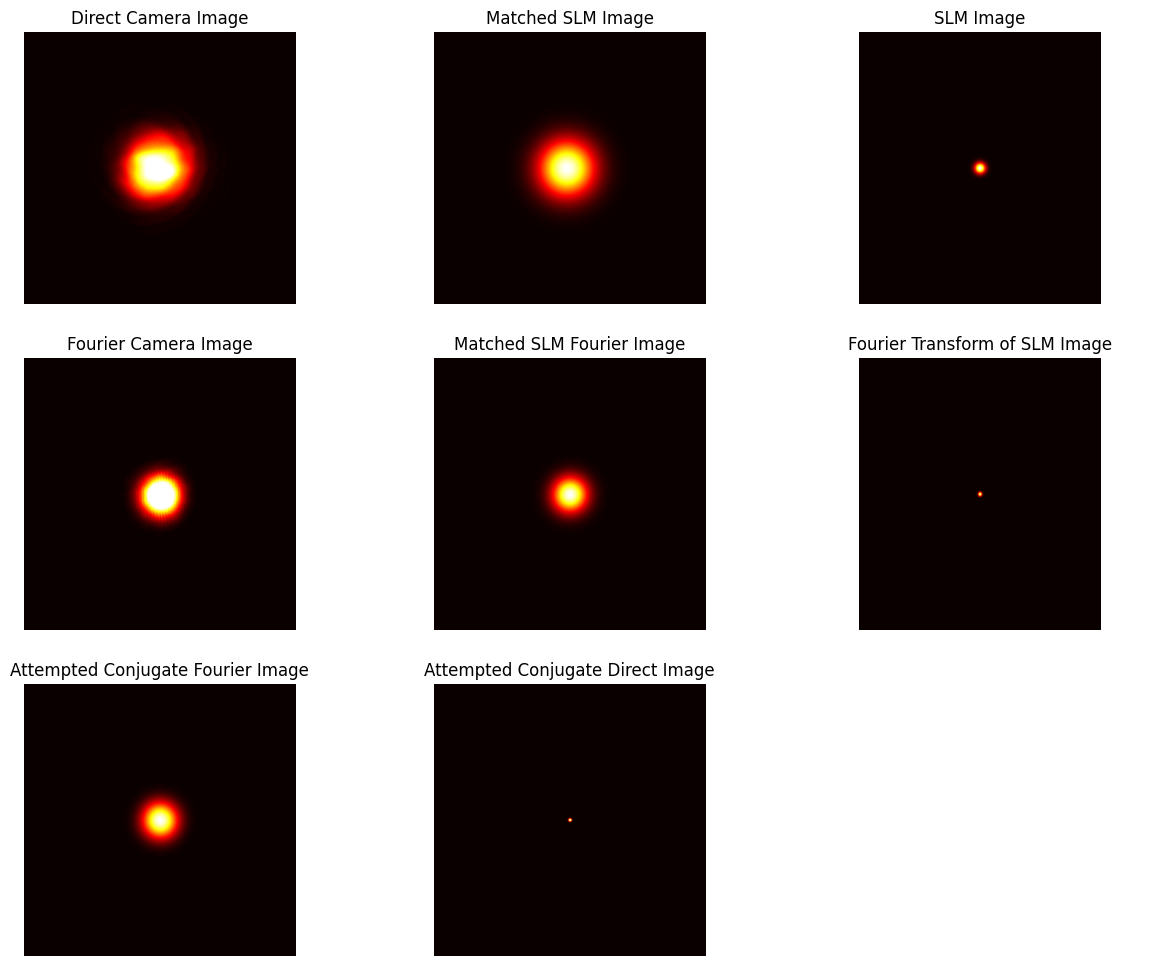

In [14]:
mode = slmcontrol.lg(xs, ys, p=0, l=0, w=30)
ft_mode = fourier_transform(mode)

camera_direct.set_exposure(200)
camera_fourier.set_exposure(400)

image_direct, image_fourier, _ = capture_images(mode, phase_transformation, camera_direct, camera_fourier, roi_direct, roi_fourier, slm, 2, 5)

slm_image_direct = affine_transform(mode, inv(A_direct), -inv(A_direct) @ t_direct, output_shape=image_direct.shape)
slm_image_fourier = affine_transform(ft_mode, inv(A_fourier), -inv(A_fourier) @ t_fourier, output_shape=image_fourier.shape)

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

axs[0, 0].imshow(image_direct, cmap="hot")
axs[0, 0].set_title("Direct Camera Image")
axs[0, 1].imshow(np.abs(slm_image_direct)**2, cmap="hot")
axs[0, 1].set_title("Matched SLM Image")
axs[0, 2].imshow(np.abs(mode)**2, cmap="hot")
axs[0, 2].set_title("SLM Image")

axs[1, 0].imshow(image_fourier, cmap="hot")
axs[1, 0].set_title("Fourier Camera Image")
axs[1, 1].imshow(np.abs(slm_image_fourier)**2, cmap="hot")
axs[1, 1].set_title("Matched SLM Fourier Image")
axs[1, 2].imshow(np.abs(ft_mode)**2, cmap="hot")
axs[1, 2].set_title("Fourier Transform of SLM Image")

alpha = find_alpha(image_direct, image_fourier, A_direct, A_fourier)

attempt_conjugate_direct_image = transform_direct_to_fourier_conjugate(
    image_direct,
    A_direct,
    A_fourier,
    alpha = alpha
)

axs[2, 0].imshow(np.abs(fourier_transform(np.sqrt(attempt_conjugate_direct_image)))**2, cmap="hot")
axs[2, 0].set_title("Attempted Conjugate Fourier Image")

axs[2, 1].imshow(attempt_conjugate_direct_image, cmap="hot")
axs[2, 1].set_title("Attempted Conjugate Direct Image")

for ax in axs.flatten():
    ax.axis("off")

plt.show()

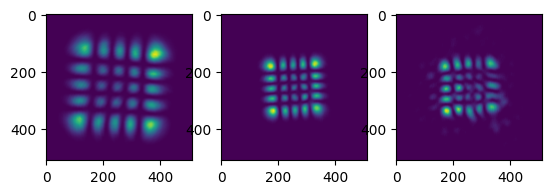

In [21]:
mode = slmcontrol.hg(xs, ys, m=4, n=4, w=30)
ft_mode = fourier_transform(mode)

camera_direct.set_exposure(100)
camera_fourier.set_exposure(200)

image_direct, image_fourier, image_phase_fourier = capture_images(mode, phase_transformation, camera_direct, camera_fourier, roi_direct, roi_fourier, slm, 2, 5)

fig, axs = plt.subplots(1, 3)
axs[0].imshow(image_direct)
axs[1].imshow(image_fourier)
axs[2].imshow(image_phase_fourier)

In [22]:
corrected_image_direct = transform_direct_to_fourier_conjugate(
    image_direct,
    A_direct,
    A_fourier,
    alpha = alpha
)

direct_amplitude = np.sqrt(corrected_image_direct).astype(np.float32)
fourier_amplitude = np.fft.fftshift(np.sqrt(image_fourier).astype(np.float32))
phase_fourier_amplitude = np.fft.fftshift(np.sqrt(image_phase_fourier).astype(np.float32))

direct_amplitude /= norm(direct_amplitude)
fourier_amplitude /= norm(fourier_amplitude)
phase_fourier_amplitude /= norm(phase_fourier_amplitude)

initial_phase = jax.random.uniform(jax.random.key(0), (10, *direct_amplitude.shape))
cropped_phase_transformation = crop_center(phase_transformation, direct_amplitude.shape[0])


predicted_phase = augmented_gs(
    direct_amplitude,
    fourier_amplitude,
    phase_fourier_amplitude,
    cropped_phase_transformation,
    initial_phase,
    100,
)

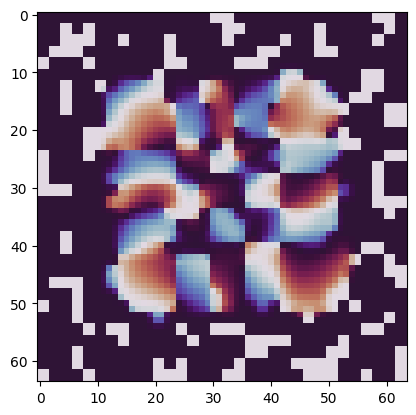

In [23]:
resized_prediction = np.angle(resize_and_center(np.exp(1j * predicted_phase), (64, 64), 2))

plt.imshow(resized_prediction, cmap="twilight")